In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
oil_prices = pd.read_csv('../data/processed/Oil/oil_prices_datastream.csv')
oil_prices['date'] = pd.to_datetime(oil_prices['date'])

oil_futures = pd.read_csv('../data/processed/Oil/oil_futures.csv')
oil_futures['date'] = pd.to_datetime(oil_futures['date'])

DGS10 = pd.read_csv('../data/processed/CCA_V2/interest_rates.csv')
DGS10['Month'] = pd.to_datetime(DGS10['Month'])

df = oil_prices.merge(oil_futures, on='date',how='left')
df = df.merge(DGS10[['Month', 'United States']], left_on='date', right_on='Month', how='left').drop(columns=['Month'])

df['DGS10'] = df['United States']

/var/folders/wy/gjw_3_n51t748hfngpz4zf0w0000gn/T/ipykernel_82191/2197519456.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oil_prices['date'] = pd.to_datetime(oil_prices['date'])
/var/folders/wy/gjw_3_n51t748hfngpz4zf0w0000gn/T/ipykernel_82191/2197519456.py:5: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  oil_futures['date'] = pd.to_datetime(oil_futures['date'])
/var/folders/wy/gjw_3_n51t748hfngpz4zf0w0000gn/T/ipykernel_82191/2197519456.py:8: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  DGS10['Month'] = pd.to_datetime(DGS10['Month'])


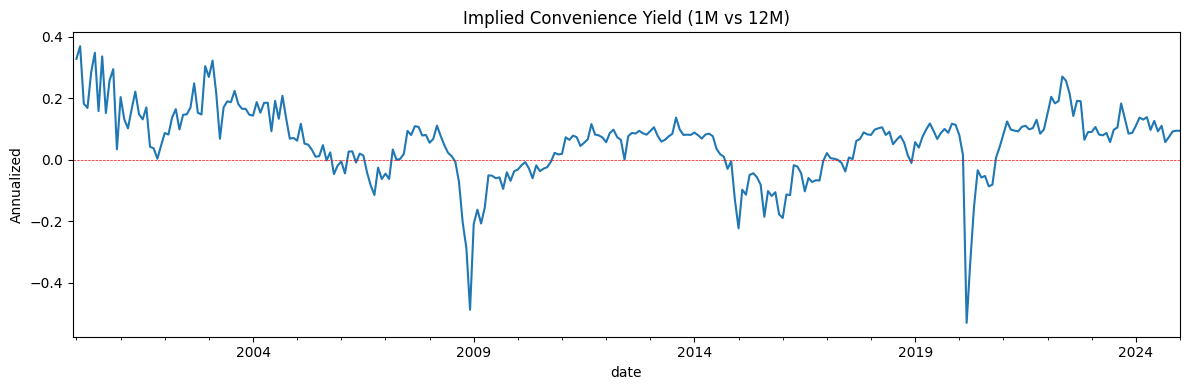

In [12]:
df = df.set_index('date')
df = df.ffill().resample('ME').last()

tenor = 12

T = tenor / 12
r = df['DGS10'] / 100
df['conv_yield'] = r - (1/T) * np.log(df[f'Brent_{tenor}m'] / df['Brent'])

df['conv_yield'].plot(figsize=(12, 4), title=f'Implied Convenience Yield (1M vs {tenor}M)')
plt.axhline(0, color='red', ls='--', lw=0.5)
plt.ylabel('Annualized')
plt.tight_layout()
plt.show()

In [13]:
df['conv_yield'].describe()

count    301.000000
mean       0.054427
std        0.115039
min       -0.530701
25%       -0.005549
50%        0.075653
75%        0.108561
max        0.368716
Name: conv_yield, dtype: float64